# 1. Importation des bibliothèques et chargement des données

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 2. Exploration initiale des données


In [6]:
# Dimensions du dataset
print("Dimensions:", df.shape)

# Informations générales
print("\nInformations générales:")
df.info()

# Statistiques descriptives
print("\nStatistiques descriptives:")
df.describe()

Dimensions: (7043, 21)

Informations générales:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# 3. Vérification des valeurs manquantes


In [7]:
# Vérifier les valeurs manquantes
print("Valeurs manquantes par colonne:")
print(df.isnull().sum())

# Vérifier la colonne cible
print("\nDistribution du Churn:")
print(df['Churn'].value_counts())

Valeurs manquantes par colonne:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Distribution du Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


# 4. Nettoyage des données

In [8]:
# Supprimer la colonne inutile customerID
df = df.drop('customerID', axis=1)

# Convertir TotalCharges en numérique (contient des espaces)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Supprimer les lignes avec valeurs manquantes (seulement 11 lignes)
df = df.dropna()

# Convertir Churn en 0/1
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Dimensions après nettoyage:", df.shape)
print("Churn après conversion:\n", df['Churn'].value_counts())

Dimensions après nettoyage: (7032, 20)
Churn après conversion:
 Churn
0    5163
1    1869
Name: count, dtype: int64


# 5. Encodage des variables catégorielles

In [9]:
# Encoder toutes les colonnes catégorielles en 0/1
df_encoded = pd.get_dummies(df, drop_first=True)

print("Dimensions après encodage:", df_encoded.shape)
print("\nColonnes:", df_encoded.columns.tolist())

Dimensions après encodage: (7032, 31)

Colonnes: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


# 6. Analyse exploratoire des données (EDA)

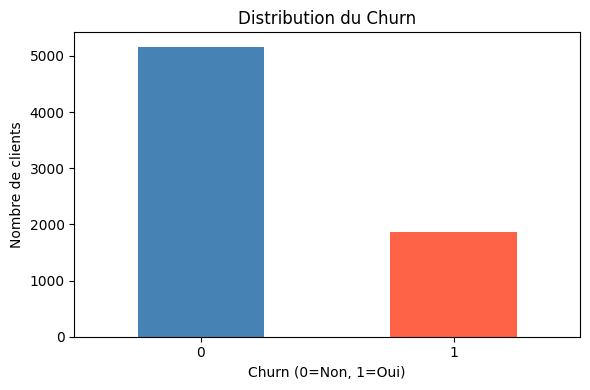

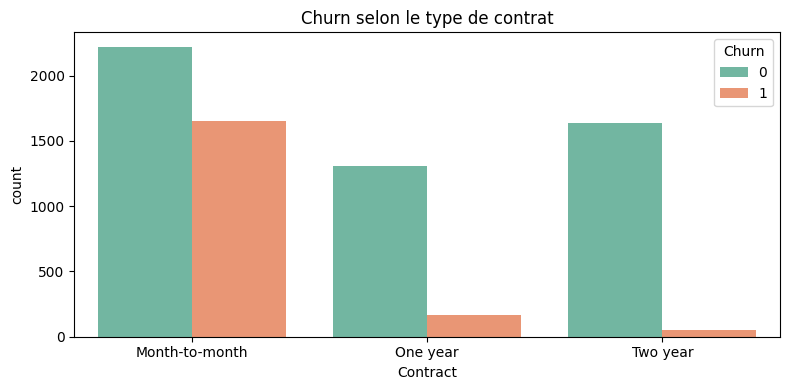

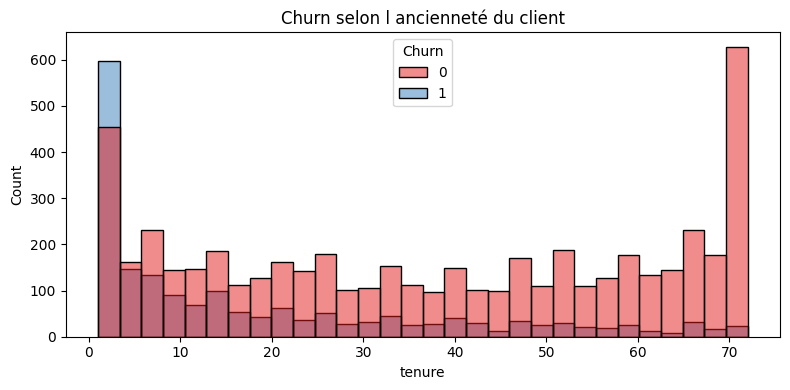

In [10]:
# Distribution du Churn
plt.figure(figsize=(6,4))
df_encoded['Churn'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Distribution du Churn')
plt.xlabel('Churn (0=Non, 1=Oui)')
plt.ylabel('Nombre de clients')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Churn selon le type de contrat
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2')
plt.title('Churn selon le type de contrat')
plt.tight_layout()
plt.show()

# Churn selon l'ancienneté (tenure)
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, palette='Set1')
plt.title('Churn selon l ancienneté du client')
plt.tight_layout()
plt.show()

# 7. Préparation des données pour la modélisation

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Séparer features (X) et cible (y)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Diviser en train (80%) et test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normaliser les données
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (5625, 30)
Test: (1407, 30)


# 8. Entraînement du modèle Random Forest

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Entraîner le modèle
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Prédictions
y_pred_rf = rf_model.predict(X_test)

# Évaluation
print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("AUC-ROC:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

AUC-ROC: 0.8156283810716929


# 9. Entraînement du modèle XGBoost

In [13]:
from xgboost import XGBClassifier

# Entraîner le modèle
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Prédictions
y_pred_xgb = xgb_model.predict(X_test)

# Évaluation
print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print("AUC-ROC:", roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]))

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1033
           1       0.59      0.55      0.57       374

    accuracy                           0.78      1407
   macro avg       0.71      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407

AUC-ROC: 0.8196701368217795


# 10. Entraînement du modèle CatBoost

In [14]:
!pip install catboost

In [15]:
from catboost import CatBoostClassifier

# Entraîner CatBoost
cat_model = CatBoostClassifier(iterations=100, random_state=42, verbose=0)
cat_model.fit(X_train, y_train)

# Prédictions
y_pred_cat = cat_model.predict(X_test)

# Évaluation
print("=== CatBoost ===")
print(classification_report(y_test, y_pred_cat))
print("AUC-ROC:", roc_auc_score(y_test, cat_model.predict_proba(X_test)[:,1]))

=== CatBoost ===
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1033
           1       0.61      0.51      0.56       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407

AUC-ROC: 0.8251678564587852


# 11. Optimisation des hyperparamètres (GridSearchCV)

In [16]:
from sklearn.model_selection import GridSearchCV

# Grille de paramètres
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5]
}

# GridSearchCV
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

# Meilleur modèle
print("Meilleurs paramètres:", grid_search.best_params_)
print("Meilleur AUC-ROC:", round(grid_search.best_score_, 4))

# Remplacer rf_model par le modèle optimisé
rf_model = grid_search.best_estimator_
y_pred_rf = rf_model.predict(X_test)
print("\n=== Random Forest Optimisé ===")
print(classification_report(y_test, y_pred_rf))
print("AUC-ROC:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]))

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Meilleurs paramètres: {'max_depth': 7, 'min_samples_split': 2, 'n_estimators': 200}
Meilleur AUC-ROC: 0.8461

=== Random Forest Optimisé ===
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.64      0.47      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.78      1407

AUC-ROC: 0.8390687525560254


# 12. Comparaison des modèles et matrices de confusion

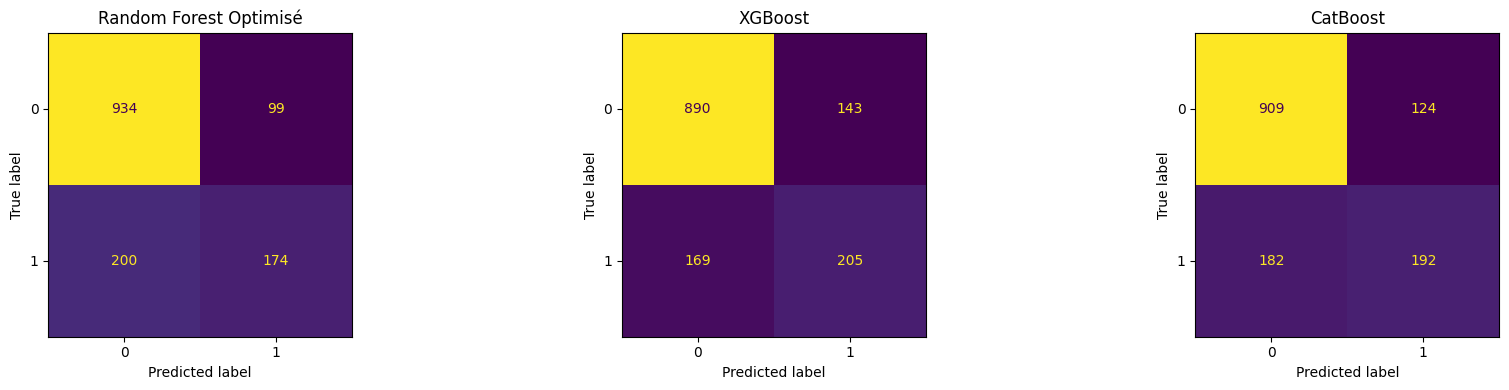

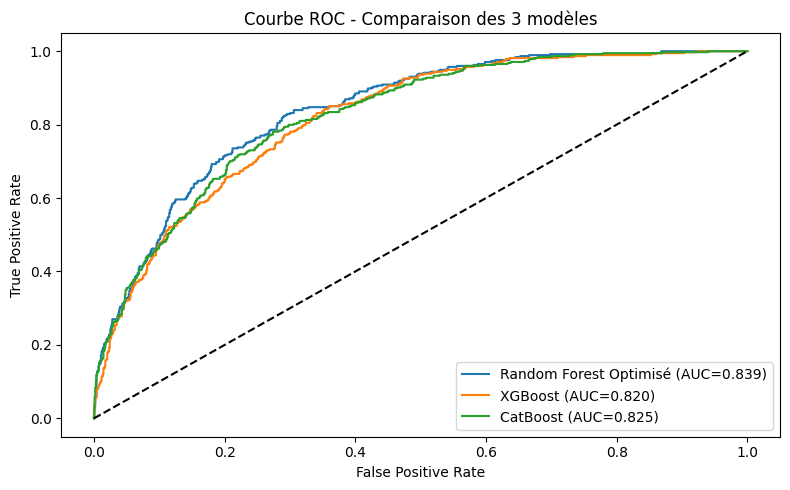

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Matrices de confusion - 3 modèles
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[0], colorbar=False)
axes[0].set_title('Random Forest Optimisé')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, ax=axes[1], colorbar=False)
axes[1].set_title('XGBoost')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_cat, ax=axes[2], colorbar=False)
axes[2].set_title('CatBoost')

plt.tight_layout()
plt.show()

# Courbe ROC - 3 modèles
from sklearn.metrics import roc_curve

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_model.predict_proba(X_test)[:,1])
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_model.predict_proba(X_test)[:,1])
fpr_cat, tpr_cat, _ = roc_curve(y_test, cat_model.predict_proba(X_test)[:,1])

plt.figure(figsize=(8,5))
plt.plot(fpr_rf, tpr_rf, label='Random Forest Optimisé (AUC=0.839)')
plt.plot(fpr_xgb, tpr_xgb, label='XGBoost (AUC=0.820)')
plt.plot(fpr_cat, tpr_cat, label='CatBoost (AUC=0.825)')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC - Comparaison des 3 modèles')
plt.legend()
plt.tight_layout()
plt.show()

# 13. Importance des variables

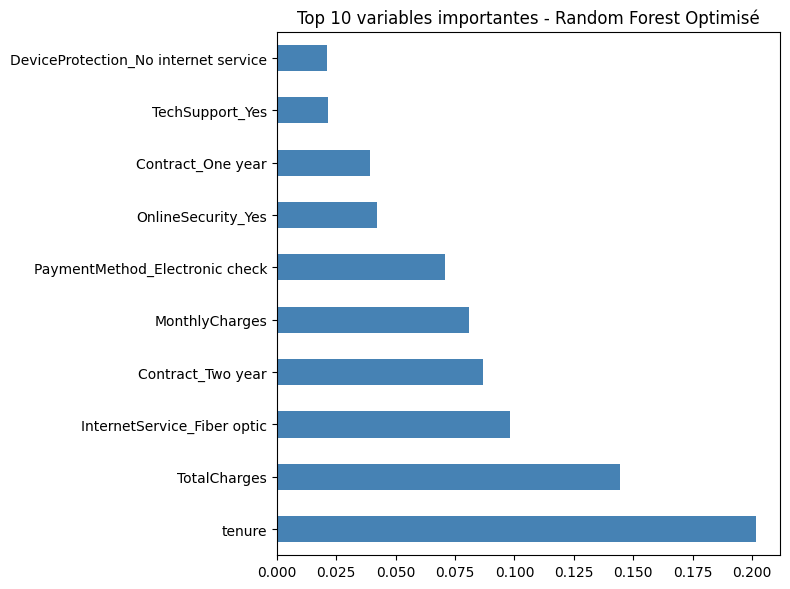

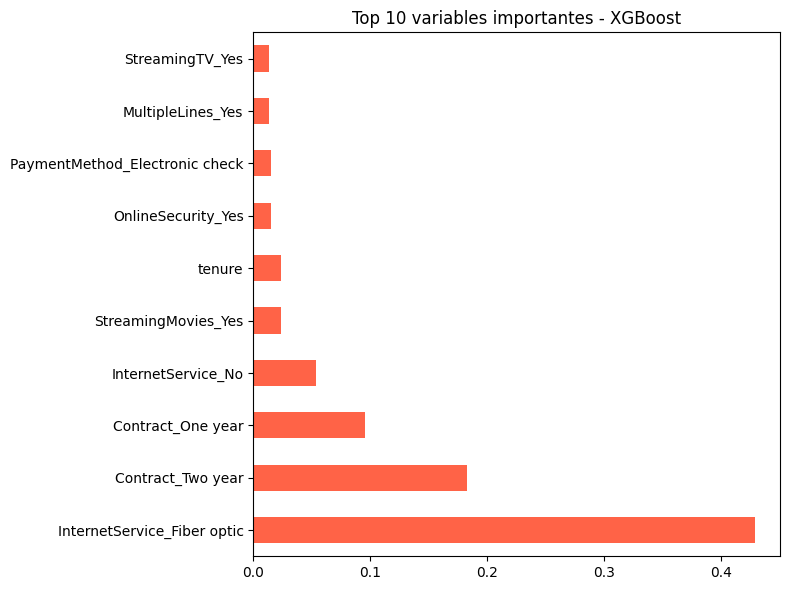

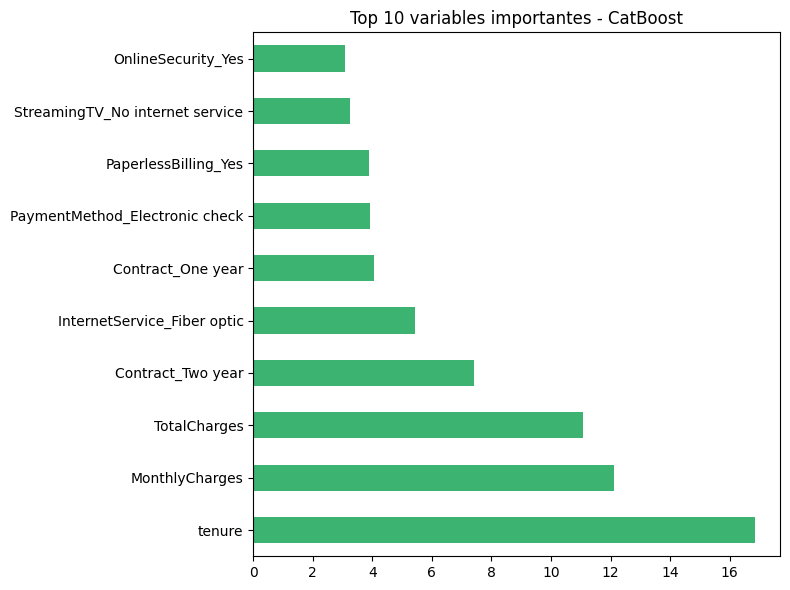

In [18]:
feature_names = df_encoded.drop('Churn', axis=1).columns

# Random Forest
importances_rf = pd.Series(rf_model.feature_importances_, index=feature_names)
plt.figure(figsize=(8,6))
importances_rf.nlargest(10).plot(kind='barh', color='steelblue')
plt.title('Top 10 variables importantes - Random Forest Optimisé')
plt.tight_layout()
plt.show()

# XGBoost
importances_xgb = pd.Series(xgb_model.feature_importances_, index=feature_names)
plt.figure(figsize=(8,6))
importances_xgb.nlargest(10).plot(kind='barh', color='tomato')
plt.title('Top 10 variables importantes - XGBoost')
plt.tight_layout()
plt.show()

# CatBoost
importances_cat = pd.Series(cat_model.feature_importances_, index=feature_names)
plt.figure(figsize=(8,6))
importances_cat.nlargest(10).plot(kind='barh', color='mediumseagreen')
plt.title('Top 10 variables importantes - CatBoost')
plt.tight_layout()
plt.show()

# 14. Sauvegarde des modèles

In [19]:
import pickle

# Sauvegarder Random Forest optimisé
with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

# Sauvegarder XGBoost
with open('xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Sauvegarder CatBoost
with open('cat_model.pkl', 'wb') as f:
    pickle.dump(cat_model, f)

# Sauvegarder le scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Sauvegarder les colonnes
with open('columns.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

print("Modèles sauvegardés avec succès ✅")

Modèles sauvegardés avec succès ✅


Téléchargement des fichiers pkl

In [20]:
from google.colab import files
files.download('rf_model.pkl')
files.download('xgb_model.pkl')
files.download('cat_model.pkl')
files.download('scaler.pkl')
files.download('columns.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>